<a href="https://colab.research.google.com/github/Mriano29/hotel_demand_forecasting_system/blob/main/data/base_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación del Dataset

Este proyecto prepara el dataset para desarrollar un sistema accesible de Gestión de Ingresos para hoteles medianos e independientes, que generalmente carecen de herramientas avanzadas para optimizar sus ingresos.

Se realizarán las siguientes etapas:
- Exploración inicial del dataset
- Limpieza de datos (nulos, duplicados, tipos, outliers)
- Feature engineering
- Análisis de correlación y selección de variables
- Evaluación de la calidad del dataset final

El objetivo final es obtener un dataset limpio y optimizado para:
- Predicción de cancelaciones
- Estimación de precios (ADR)
- Modelado de ocupación

##Indice

despues

##**1.0 — Exploración inicial**

### 1.1 — Carga de datos

Se carga el dataset desde una fuente externa (GitHub) para garantizar reproducibilidad.

In [426]:
import pandas as pd

url = "https://raw.githubusercontent.com/Mriano29/hotel_demand_forecasting_system/refs/heads/main/data/hotel_booking.csv"

df = pd.read_csv(url)

### 1.2 — Visualización de las primeras filas

Se visualizan las primeras filas del dataset para realizar una validación preliminar de la carga de datos y comprender la estructura general de la información disponible.

In [427]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


### 1.3 — Forma del dataset

Se analiza la dimensión inicial del dataset para conocer el volumen total de información disponible antes de aplicar cualquier transformación o limpieza.

In [428]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 119390
Columnas: 36


### 1.4 — Información general del dataset

Se utiliza el método `info()` para obtener una visión estructural completa del dataset y evaluar la calidad inicial de los datos.

A partir de esta inspección se detectaron varios aspectos relevantes para las siguientes fases del proyecto:

* Presencia de valores nulos en las variables `children`, `country`, `agent` y `company`

* Variables temporales almacenadas como texto

* Columnas con información personal identificable (PII)

In [429]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### 1.5 — Estadísticas descriptivas iniciales

Se calculan estadísticas descriptivas sobre todas las variables del dataset mediante `describe(include='all')`, con el objetivo de obtener una visión global del comportamiento de los datos antes de iniciar el proceso de limpieza y transformación.



* La variable `is_canceled` presenta una media de 0.37, lo que indica que aproximadamente el 37% de las reservas fueron canceladas

* La variable `lead_time` alcanza valores máximos de hasta 737 días, reflejando reservas realizadas con una antelación muy elevada

* La variable `adr` presenta valores negativos y máximos extremadamente altos (5400), lo que sugiere la existencia de anomalías y posibles outliers que deberán analizarse posteriormente

* Variables como `adults`, `stays_in_week_nights` o `stays_in_weekend_nights` contienen valores máximos poco habituales, lo que requiere validación durante la fase de limpieza

* En las variables categóricas se observa una fuerte concentración en determinadas categorías, como `City Hotel` en hotel o `Transient` en customer_type

* También se detecta la presencia de columnas con una elevada cardinalidad, como `email`, `phone-number` o `name`, que posteriormente serán eliminadas por no aportar valor predictivo y contener información personal identificable

In [430]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,119390.000000,119390.000000,119390.000000,119390,119390,119390,119390,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,4,NaN,NaN,NaN,3,926,81503,115889,119390,9000
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,Transient,NaN,NaN,NaN,Check-Out,2015-10-21,Michael Johnson,Michael.C@gmail.com,422-804-6403,************3627
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,89613,NaN,NaN,NaN,75166,1461,48,6,1,28
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,101.831122,0.062518,0.571363,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,50.535790,0.245291,0.792798,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,-6.380000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,69.290000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,94.575000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,126.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN


### 1.6 — Análisis de valores nulos

Se realiza un análisis específico de los valores faltantes presentes en el dataset con el objetivo de identificar qué variables contienen datos incompletos y cuantificar su impacto sobre el total de registros.

Los resultados muestran que únicamente cuatro variables presentan valores nulos:

* `company`: 112.593 valores faltantes.
* `agent`: 16.340 valores faltantes.
* `country`: 488 valores faltantes.
* `children`: 4 valores faltantes.

La elevada cantidad de nulos en `company` y `agent` resulta coherente con la naturaleza del negocio, ya que muchas reservas fueron realizadas directamente por clientes particulares sin intermediarios ni empresas asociadas.

Por otro lado, los valores faltantes en `country` y `children` representan una proporción muy reducida respecto al total del dataset, por lo que podrán tratarse posteriormente mediante estrategias de imputación sencillas.

In [431]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4


### 1.7 — Detección de valores duplicados

In [432]:
duplicated_rows = df.duplicated().sum()

print(f"Registros duplicados: {duplicated_rows}")

Registros duplicados: 0


### 1.8 — Validación de consistencia lógica en registros de reservas

En esta sección se evalúa la coherencia interna de los registros del dataset con el objetivo de detectar observaciones que, aunque no presentan valores nulos, no son consistentes desde un punto de vista operativo.

Este tipo de validación permite identificar registros que no representan situaciones reales de negocio, como reservas sin huéspedes o sin estancia efectiva, y que por tanto pueden introducir ruido en los modelos predictivos.

La eliminación de estas inconsistencias contribuye a mejorar la calidad del dataset y a garantizar que el análisis posterior se base en datos coherentes con la realidad del sector hotelero.

#### 1.8.1 — Detección de reservas sin huéspedes

Se identifican 180 registros en los que no se especifica ningún huésped asociado a la reserva (`adults`, `children` y `babies` igual a cero). Estas observaciones no son coherentes con el proceso de reserva hotelera y se consideran inválidas para el análisis.

In [433]:
no_guests = df[
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
]

print(f"Reservas sin huéspedes: {no_guests.shape[0]}")

Reservas sin huéspedes: 180


#### 1.8.2 — Detección de reservas con sin noches de estancia

Se detectan 715 registros con duración de estancia igual a cero, donde no se registran noches en `stays_in_week_nights` ni en `stays_in_weekend_nights`. Estas observaciones no representan estancias reales y se eliminan del dataset.

In [434]:
zero_nights = df[
    (df["stays_in_week_nights"] == 0) &
    (df["stays_in_weekend_nights"] == 0)
]

print(f"Reservas con 0 noches: {zero_nights.shape[0]}")

Reservas con 0 noches: 715


### 1.9 — Análisis de anomalías y valores extremos en ADR

En esta sección se analiza en profundidad la variable `adr` (Average Daily Rate), una de las variables más relevantes del dataset ya que representa el precio medio diario pagado por cada reserva hotelera.

El objetivo de este análisis es comprender la distribución de los precios, identificar valores extremos y detectar posibles anomalías que puedan afectar al rendimiento de los modelos predictivos.

Dado que `adr` es una variable clave en problemas de Revenue Management y predicción de ingresos, su tratamiento requiere especial cuidado, evitando eliminaciones automáticas que puedan eliminar información válida del negocio (como habitaciones premium o temporadas de alta demanda).

#### 1.9.1 — Distribución estadística y análisis de percentiles de ADR

Se analiza la distribución de la variable adr mediante estadísticas descriptivas y percentiles para comprender su comportamiento general.

Los resultados muestran una media de 101.83 y una mediana de 94.57, lo que indica una ligera asimetría hacia valores altos.

El análisis de percentiles revela que el 95% de las reservas tiene un ADR inferior a 193.5,
el 99% está por debajo de 252,
y el 99.9% no supera 326.2.

Sin embargo, se observa un valor máximo de 5400, muy alejado del resto de la distribución, lo que sugiere la presencia de valores extremos que deben ser analizados con precaución en el contexto del negocio hotelero.

In [435]:
df["adr"].describe(percentiles=[0.95, 0.99, 0.999])

,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
50%,94.575000
95%,193.500000
99%,252.000000
99.9%,326.201630
max,5400.000000


#### 1.9.2 — Detección de valores negativos en ADR

Se analiza la existencia de valores negativos en la variable `adr`, ya que desde un punto de vista económico un precio diario negativo no tiene sentido en un contexto hotelero.

El análisis detecta un único registro con valor negativo, el cual se considera una anomalía o error de registro.

Este tipo de observaciones será eliminado durante la fase de limpieza para evitar distorsiones en el modelado predictivo.

In [436]:
negative_adr = df[df["adr"] < 0]

print(f"Reservas con ADR negativo: {negative_adr.shape[0]}")

Reservas con ADR negativo: 1


### 1.10 — Análisis de variables temporales del dataset

Se analizan las variables relacionadas con la fecha de llegada con el objetivo de comprender cómo está estructurada la información temporal en el dataset.

El dataset no contiene una variable de fecha unificada, sino que la información temporal se encuentra fragmentada en varias columnas: año, mes, semana del año y día del mes.

Este formato requiere una transformación previa antes de poder realizar análisis temporales avanzados o integrar el dataset con fuentes externas como AEMET, ISTAC o AENA, que trabajan con fechas completas y series temporales estándar.

In [437]:
print("Año de llegada (arrival_date_year):")
print(df["arrival_date_year"].unique())

print("\nMes de llegada (arrival_date_month):")
print(df["arrival_date_month"].unique())

print("\nSemana del año (arrival_date_week_number) - muestra:")
print(df["arrival_date_week_number"].unique()[:20])

print("\nDía del mes (arrival_date_day_of_month) - muestra:")
print(df["arrival_date_day_of_month"].unique()[:20])

Año de llegada (arrival_date_year):
[2015 2016 2017]

Mes de llegada (arrival_date_month):
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']

Semana del año (arrival_date_week_number) - muestra:
[27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]

Día del mes (arrival_date_day_of_month) - muestra:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


### 1.11 — Análisis de tipos de variables

Se realiza un análisis de los tipos de datos presentes en el dataset con el objetivo de comprender cómo se representa cada variable y detectar posibles inconsistencias entre el tipo técnico almacenado y el significado real de la información.

#### 1.11.1 — Inspección general de tipos de datos

Se inspeccionan los tipos de datos almacenados en cada columna del dataset para identificar variables numéricas, categóricas y temporales.

In [438]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


#### 1.11.2 — Clasificación de variables por tipo

Se agrupan las variables según su tipo de dato para facilitar el análisis estructural del dataset.

In [439]:
categorical_columns = df.select_dtypes(include=["object"]).columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Variables categóricas potenciales:")
print(categorical_columns)

print("\nVariables numéricas:")
print(numeric_columns)

Variables categóricas potenciales:
Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date', 'name', 'email', 'phone-number',
       'credit_card'],
      dtype='object')

Variables numéricas:
Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')


#### 1.11.3 — Identificación de variables con representación semántica especial

Se identifican variables cuya representación técnica no refleja correctamente su significado real dentro del contexto del negocio hotelero.

Algunas columnas almacenadas como valores numéricos representan en realidad identificadores categóricos y no magnitudes continuas. Este es el caso de variables como `agent` y `company`, que identifican intermediarios y empresas asociadas a determinadas reservas.

### 1.12 — Informe final de salud del dataset



Se realiza un informe global del estado del dataset tras las fases iniciales de carga, exploración y limpieza, con el objetivo de consolidar en una única vista las principales métricas estructurales y de calidad de los datos.

Este resumen permite verificar de forma rápida el impacto de las transformaciones realizadas y confirmar que el dataset se encuentra en condiciones adecuadas para las siguientes fases de análisis y modelado.

El informe muestra los siguientes resultados:

* El dataset mantiene un total de 119.390 registros y 36 variables, lo que confirma que no se ha producido pérdida estructural de información relevante durante el proceso de limpieza

* No se detectan registros duplicados, lo que garantiza la integridad de las observaciones

* Se observa la presencia de valores nulos en el dataset original

* La variable adr presenta un valor mínimo negativo (-6.38) y un valor máximo extremadamente elevado (5400), lo que refuerza la necesidad del análisis específico de outliers

In [440]:
health_report = pd.DataFrame({
    "Métrica": [
        "Registros",
        "Variables",
        "Duplicados",
        "Valores nulos",
        "ADR mínimo",
        "ADR máximo"
    ],
    "Valor": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        round(df["adr"].min(), 2),
        round(df["adr"].max(), 2)
    ]
})

health_report

,Métrica,Valor
0,Registros,119390.00
1,Variables,36.00
2,Duplicados,0.00
3,Valores nulos,129425.00
4,ADR mínimo,-6.38
5,ADR máximo,5400.00


## **2.0 — Limpieza**


En esta sección se realiza el proceso de limpieza y depuración del dataset con el objetivo de garantizar la calidad, coherencia y consistencia de los datos antes de su utilización en las fases de análisis y modelado.

El proceso incluye la eliminación de duplicados, tratamiento de valores nulos, detección y eliminación de inconsistencias lógicas, tratamiento de valores extremos en variables críticas, corrección de tipos de datos y eliminación de variables no relevantes o sensibles.

### 2.1 — Eliminación de registros duplicados

El análisis inicial confirma que no existen registros duplicados en el dataset, lo que indica una buena calidad estructural de los datos originales.

Por este motivo, no se requiere la eliminación de ninguna observación en esta etapa, aunque se mantiene esta validación como parte del proceso estándar de limpieza de datos en pipelines de Machine Learning.

In [441]:
duplicated_rows = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicated_rows}")

Registros duplicados encontrados: 0


### 2.1 — Manejo de valores nulos

Se procede al tratamiento de los valores nulos detectados previamente en el dataset, aplicando estrategias específicas en función del significado de cada variable.

Las variables `children` y `country` se imputan con valores por defecto (0 y "Unknown" respectivamente), ya que su ausencia puede interpretarse como la no presencia de información adicional o desconocimiento del dato en el momento de la reserva.

Las variables `agent` y `company`, relacionadas con intermediarios de reserva, se imputan con 0, representando la ausencia de agente o empresa asociada.

Este enfoque permite preservar la totalidad de los registros del dataset sin introducir distorsiones significativas en la distribución de los datos, manteniendo la coherencia del conjunto de información para fases posteriores de análisis y modelado.

In [442]:
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

df.isnull().sum()[df.isnull().sum() > 0]

,0


### 2.2 — Eliminación de reservas sin huéspedes

Se eliminan aquellos registros en los que no existe ningún huésped asociado a la reserva (adultos, niños y bebés iguales a cero).

Estas observaciones no son coherentes con el proceso real de reserva hotelera, por lo que se consideran registros inválidos y se eliminan del dataset.

In [443]:
df = df[
    ~(
        (df["adults"] == 0) &
        (df["children"] == 0) &
        (df["babies"] == 0)
    )
]

df.shape

(119210, 36)

### 2.3 — Eliminación de reservas sin noches de estancia

Se eliminan las reservas en las que no se registra ninguna noche de estancia, es decir, aquellas donde tanto las noches entre semana como las de fin de semana son igual a cero.

Estas observaciones no representan estancias reales en el hotel y, por tanto, no aportan información útil para el modelado.

In [444]:
df = df[
    ~(
        (df["stays_in_week_nights"] == 0) &
        (df["stays_in_weekend_nights"] == 0)
    )
]

df.shape

(118565, 36)

### 2.4 — Tratamiento de valores extremos en ADR

Se detecta la existencia de valores negativos, los cuales no son coherentes desde el punto de vista económico y son eliminados del dataset.

Los valores extremadamente altos serán analizados en función de percentiles en fases posteriores, evitando la aplicación de reglas agresivas que puedan eliminar información relevante del negocio hotelero.

In [445]:
df = df[df["adr"] >= 0]

df.shape

(118564, 36)

### 2.5 — Construcción de variable temporal unificada

#### 2.5.1 — Conversión del mes de llegada a formato numérico

La variable `arrival_date_month` se encuentra almacenada en formato texto utilizando los nombres de los meses en inglés.

Para facilitar la construcción de una fecha completa y permitir operaciones temporales posteriores, se convierte cada mes a su representación numérica correspondiente.

Esta transformación permite estandarizar la información temporal y preparar los datos para la creación de una variable datetime unificada.

In [446]:
import calendar

df["arrival_date_month_num"] = df["arrival_date_month"].apply(
    lambda x: list(calendar.month_name).index(x)
)

#### 2.5.2 — Conversión del mes de llegada a formato numérico

Se crea la variable arrival_date combinando las columnas de año, mes y día de llegada en una única variable de tipo datetime.

La creación de esta fecha unificada permite representar cada reserva como un punto temporal concreto, facilitando el análisis cronológico y la integración futura con datasets externos basados en series temporales.

Además, esta transformación habilita futuras tareas de feature engineering relacionadas con estacionalidad, tendencias y comportamiento temporal de la demanda hotelera.

In [447]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month_num"].astype(str) + "-" +
    df["arrival_date_day_of_month"].astype(str),
    errors="coerce"
)

df[["arrival_date"]].head()

,arrival_date
2,2015-07-01
3,2015-07-01
4,2015-07-01
5,2015-07-01
6,2015-07-01


#### 2.5.3 — Ordenación cronológica del dataset

Una vez construida la variable temporal unificada, el dataset se ordena cronológicamente según la fecha de llegada de las reservas.

Esta organización facilita posteriores análisis temporales y mejora la coherencia del conjunto de datos para tareas relacionadas con series temporales y modelado de demanda.

In [448]:
df = df.sort_values("arrival_date")

#### 2.5.4 — Eliminación de variables temporales redundantes

Tras la creación de la variable arrival_date, las columnas temporales originales dejan de ser necesarias al quedar representadas dentro de la nueva estructura datetime.

In [449]:
df = df.drop(columns=[
    "arrival_date_year",
    "arrival_date_month",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "arrival_date_month_num"
])

### 2.6 — Conversión de variables categóricas

Se realiza la conversión de determinadas variables al tipo `category` de Pandas con el objetivo de representar correctamente la naturaleza categórica de los datos y optimizar el uso de memoria del dataset.

In [450]:
categorical_cols = list(
    df.select_dtypes(include='object').columns
)

categorical_cols.extend(["agent", "company"])

for col in categorical_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118564 entries, 2 to 117424
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           118564 non-null  category      
 1   is_canceled                     118564 non-null  int64         
 2   lead_time                       118564 non-null  int64         
 3   stays_in_weekend_nights         118564 non-null  int64         
 4   stays_in_week_nights            118564 non-null  int64         
 5   adults                          118564 non-null  int64         
 6   children                        118564 non-null  float64       
 7   babies                          118564 non-null  int64         
 8   meal                            118564 non-null  category      
 9   country                         118564 non-null  category      
 10  market_segment                  118564 non-null  category    

### 2.7 — Eliminación de variables de información personal (PII)

Se eliminan del dataset aquellas variables que contienen información personal identificable de los clientes (PII, Personally Identifiable Information), como nombres, correos electrónicos, números de teléfono o datos de tarjetas de crédito.

Este tipo de información no aporta valor predictivo al problema de negocio planteado y su uso no es adecuado desde el punto de vista ético y de protección de datos.

In [451]:
pii_columns = [
    "name",
    "email",
    "phone-number",
    "credit_card"
]

df = df.drop(columns=pii_columns)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118564 entries, 2 to 117424
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           118564 non-null  category      
 1   is_canceled                     118564 non-null  int64         
 2   lead_time                       118564 non-null  int64         
 3   stays_in_weekend_nights         118564 non-null  int64         
 4   stays_in_week_nights            118564 non-null  int64         
 5   adults                          118564 non-null  int64         
 6   children                        118564 non-null  float64       
 7   babies                          118564 non-null  int64         
 8   meal                            118564 non-null  category      
 9   country                         118564 non-null  category      
 10  market_segment                  118564 non-null  category    

### 2.8 — Consolidación del estado del dataset tras la limpieza

En esta sección se realiza una consolidación global del estado del dataset después de las operaciones de limpieza aplicadas.

Se resumen las principales métricas estructurales con el objetivo de verificar la integridad del conjunto de datos tras la eliminación de valores nulos, registros inconsistentes y variables no relevantes.

In [452]:
cleaning_summary = pd.DataFrame({
    "Métrica": [
        "Registros finales",
        "Variables finales",
        "Valores nulos totales",
        "Duplicados",
        "Variables eliminadas (PII)",
        "ADR mínimo",
        "ADR máximo"
    ],
    "Valor": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        4,  # name, email, phone-number, credit_card
        round(df["adr"].min(), 2),
        round(df["adr"].max(), 2)
    ]
})

cleaning_summary

,Métrica,Valor
0,Registros finales,118564.0
1,Variables finales,29.0
2,Valores nulos totales,0.0
3,Duplicados,31926.0
4,Variables eliminadas (PII),4.0
5,ADR mínimo,0.0
6,ADR máximo,5400.0


### 2.9 — Impacto de las variables PII en la identificación de duplicados estructurales

El análisis de duplicados muestra que la presencia de variables de información personal (PII) enmascara la existencia de registros estructuralmente similares dentro del dataset.

Al eliminar estas variables, se observa la repetición de patrones de reserva basados en variables de negocio, lo cual es coherente con la naturaleza del dominio hotelero, donde múltiples reservas pueden compartir características operativas idénticas.

Por tanto, la detección de duplicados depende directamente del nivel de granularidad del dataset analizado.


## **3.0 — Análisis y tratamiento de valores atípicos**


###3.1 — Selección de variables numéricas relevantes

Se seleccionan las variables numéricas del dataset y se realiza un análisis estadístico descriptivo.

Este paso permite obtener una visión global de la distribución de los datos, identificando asimetrías, dispersión y posibles valores extremos en variables relevantes como ADR, lead time o duración de estancia.

In [453]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols].describe()

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000,118564.000000
mean,0.372592,104.505069,0.932070,2.512761,1.860008,0.104197,0.007962,0.029503,0.087632,0.137166,0.218346,2.333035,102.524728,0.062759,0.571936
std,0.483497,106.915647,0.995426,1.893239,0.575444,0.399121,0.097560,0.169212,0.847176,1.500696,0.637611,17.642856,50.004752,0.245744,0.793283
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000
50%,0.000000,70.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000
75%,1.000000,161.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,709.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,18.000000,391.000000,5400.000000,8.000000,5.000000


###3.2 — Detección visual de outliers

Se representan las principales variables numéricas mediante diagramas de caja con el objetivo de identificar visualmente la presencia de valores extremos.

Se observa una alta dispersión en variables como ADR y lead time, así como valores atípicos en el número de adultos y la duración de la estancia.

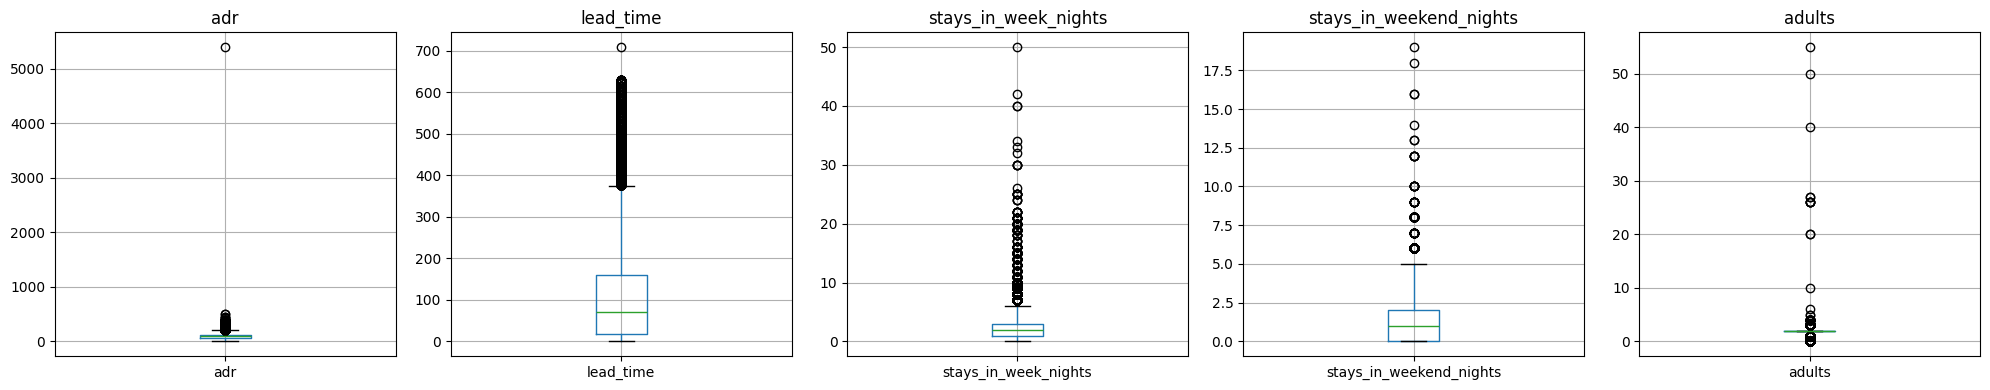

In [454]:
import matplotlib.pyplot as plt

cols_to_plot = [
    "adr",
    "lead_time",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "adults"
]

fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(20, 4))

for ax, col in zip(axes, cols_to_plot):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

###3.3 — Detección de outliers mediante percentiles

In [455]:
import numpy as np

cols_outliers = [
    "adr",
    "lead_time",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
    "adults"
]

outlier_limits = {}

for col in cols_outliers:
    p99 = df[col].quantile(0.99)
    p999 = df[col].quantile(0.999)

    outlier_limits[col] = {
        "p99": p99,
        "p999": p999
    }

    print(f"\n{col}")
    print(f"P99: {p99}")
    print(f"P99.9: {p999}")


adr
P99: 252.0
P99.9: 326.40429000000336

lead_time
P99: 444.0
P99.9: 605.0

stays_in_week_nights
P99: 10.0
P99.9: 19.0

stays_in_weekend_nights
P99: 4.0
P99.9: 6.0

adults
P99: 3.0
P99.9: 3.0


###3.4 — Tratamiento de outliers en ADR basado en percentiles

Se aplica un tratamiento de outliers en la variable `adr` utilizando percentiles extremos (P1 y P99).

Este enfoque permite eliminar únicamente los valores más extremos de la distribución, evitando la pérdida de información relevante del negocio.

A diferencia de métodos más agresivos, este criterio:

* Mantiene la estructura general del mercado hotelero
* Conserva reservas de alto valor económico
* Reduce el impacto de valores claramente anómalos

In [456]:
# Definimos percentiles extremos
p1 = df["adr"].quantile(0.01)
p99 = df["adr"].quantile(0.99)

print(f"Límite inferior (P1): {p1}")
print(f"Límite superior (P99): {p99}")

# Filtrado de outliers extremos
df = df[(df["adr"] >= p1) & (df["adr"] <= p99)]

print(f"Shape tras tratamiento de outliers en ADR: {df.shape}")

Límite inferior (P1): 1.926000000000022
Límite superior (P99): 252.0
Shape tras tratamiento de outliers en ADR: (116210, 29)


###3.5 — Justificación del uso de percentiles frente a IQR

El método IQR, aunque ampliamente utilizado en estadística clásica, presenta limitaciones en este contexto:

No considera el significado económico de los datos
Puede eliminar observaciones válidas de alto valor (hoteles premium, temporadas altas)
Asume distribuciones simétricas, lo cual no se cumple en variables de precios turísticos

Por el contrario, el enfoque basado en percentiles:

* Permite conservar la estructura real del mercado
* Es más robusto frente a distribuciones asimétricas
* Se adapta mejor a problemas de revenue management

Por estas razones, se prioriza un enfoque conservador que mantiene la integridad del dataset sin eliminar información potencialmente relevante para el modelado.

###3.6 — Verificación del tratamiento de outliers en ADR

En esta sección se valida el resultado del tratamiento de outliers aplicado a la variable adr.

Para evitar inconsistencias metodológicas, la verificación se realiza utilizando los límites originales definidos antes del filtrado (percentiles P1 y P99 calculados en la fase de análisis).

Se comprueba:

* La distribución estadística de la variable tras la limpieza
* El rango mínimo y máximo actual
* La existencia de posibles valores fuera del rango definido inicialmente

Este enfoque garantiza una validación coherente del proceso de limpieza, evitando errores derivados del recalculo dinámico de percentiles sobre el dataset ya filtrado.

In [457]:
# Límites usados originalmente en el tratamiento
p1 = 1.926
p99 = 252.0

# Resumen estadístico tras el filtrado
print("Resumen tras tratamiento de outliers en ADR:\n")
print(df["adr"].describe())

# Verificación de rangos reales del dataset
print("\nRango real de ADR:")
print("Min:", df["adr"].min())
print("Max:", df["adr"].max())

# Comprobación de que todos los valores están dentro del rango definido inicialmente
out_of_range = df[(df["adr"] < p1) | (df["adr"] > p99)]

print("\nNúmero de valores fuera del rango permitido:")
print(out_of_range.shape[0])

Resumen tras tratamiento de outliers en ADR:

count    116210.000000
mean        101.688476
std          43.079469
min           2.000000
25%          70.000000
50%          95.000000
75%         125.100000
max         252.000000
Name: adr, dtype: float64

Rango real de ADR:
Min: 2.0
Max: 252.0

Número de valores fuera del rango permitido:
0


###3.7 — Conclusión del tratamiento de valores anómalos

El tratamiento de outliers se ha aplicado exclusivamente sobre la variable ADR debido a su impacto directo en la estimación de ingresos y su sensibilidad a valores inconsistentes.
El resto de variables numéricas presentan valores extremos, pero estos reflejan comportamiento real del negocio hotelero y no errores de registro, por lo que se mantienen sin modificación para preservar la información del dataset.

##**4.0 — Análisis de correlación**

El objetivo de esta sección es analizar las relaciones entre las variables numéricas del dataset mediante una matriz de correlación.

Este análisis permite identificar:

* Relaciones entre variables predictoras
* Posibles problemas de multicolinealidad
* Variables más relacionadas con los objetivos del modelo, especialmente la cancelación de reservas y el precio medio

Se utilizará la correlación de Pearson como medida principal, ya que permite evaluar relaciones lineales entre variables numéricas.

####4.1 — Matríz de correlación

La matriz de correlación permite analizar las relaciones lineales entre las variables numéricas del dataset con el objetivo de identificar patrones de dependencia, posibles redundancias y relaciones relevantes con las variables objetivo.

En términos generales, se observa que la mayoría de las variables presentan correlaciones bajas o moderadas entre sí, lo que indica que no existe un problema significativo de multicolinealidad. Este resultado es positivo, ya que sugiere que las variables aportan información complementaria y no redundante.

En relación con la variable objetivo `is_canceled`, se identifican correlaciones leves pero coherentes con el comportamiento del negocio. Destaca especialmente la relación positiva con `lead_time`, lo que indica que las reservas realizadas con mayor antelación tienden a presentar una mayor probabilidad de cancelación. Por otro lado, variables como el `número de solicitudes especiales` o la `necesidad de plaza de aparcamiento` muestran una relación negativa, sugiriendo menor propensión a cancelar en estos casos.

Respecto a la variable `adr`, se observan correlaciones moderadas con variables relacionadas con el tamaño del grupo y el tipo de estancia, lo que indica que el precio medio está influenciado principalmente por características estructurales de la reserva más que por el comportamiento del cliente.

En cuanto a las variables de estancia, se aprecia una relación lógica entre las noches entre semana y fin de semana, así como una ligera correlación entre el número de adultos y niños, reflejando patrones habituales en reservas familiares o de grupos.

En conjunto, el análisis sugiere que el dataset no presenta problemas graves de redundancia entre variables y que la información está distribuida de forma equilibrada, lo que lo hace adecuado para tareas de modelado predictivo.

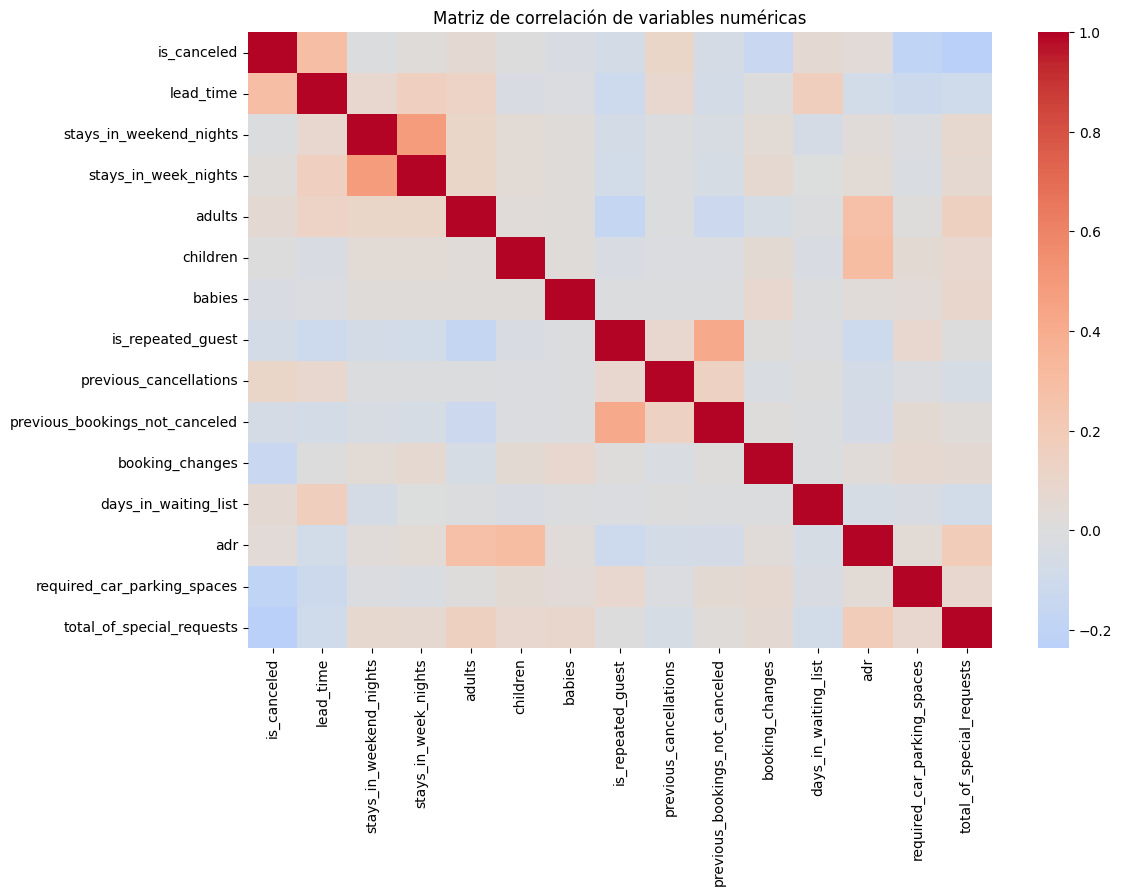

In [470]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selección de variables numéricas
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Matriz de correlación
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

####4.2 — Correlación con variables objetivo

In [471]:
target_cols = ["is_canceled", "adr"]

corr_target = df[num_cols].corr()[target_cols].sort_values(by="is_canceled", ascending=False)

corr_target

,is_canceled,adr
is_canceled,1.000000,0.034792
lead_time,0.291347,-0.085471
previous_cancellations,0.111178,-0.073497
adults,0.057715,0.279524
days_in_waiting_list,0.054498,-0.045931
adr,0.034792,1.000000
stays_in_week_nights,0.017886,0.043026
children,0.001870,0.304164
stays_in_weekend_nights,-0.008171,0.030270
babies,-0.031883,0.030809


## Balanceo del dataset

###Reservas canceladas

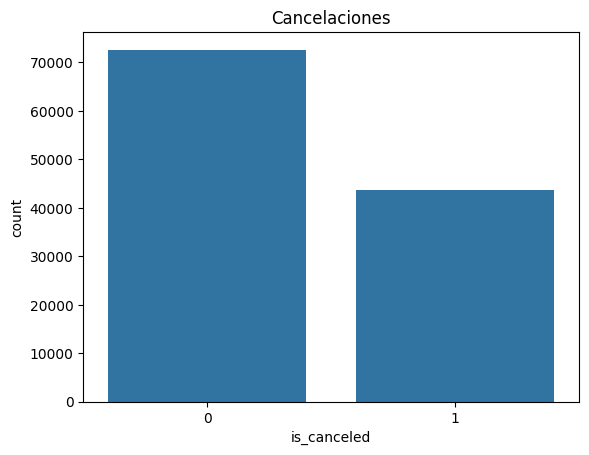

In [462]:
sns.countplot(x='is_canceled', data=df)
plt.title("Cancelaciones")
plt.show()

###Tipos de hotel

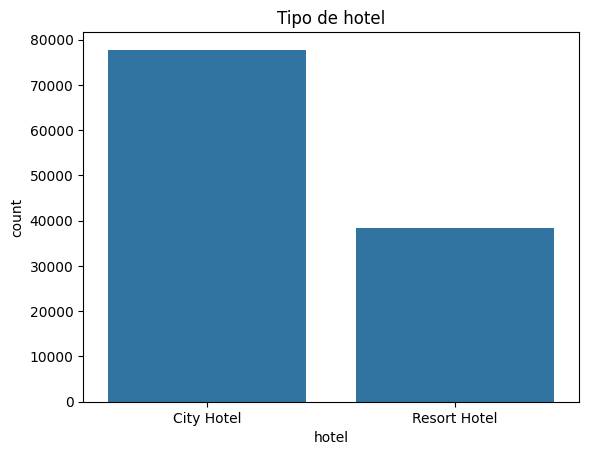

In [463]:
sns.countplot(x='hotel', data=df)
plt.title("Tipo de hotel")
plt.show()

### Tarifa media diaria

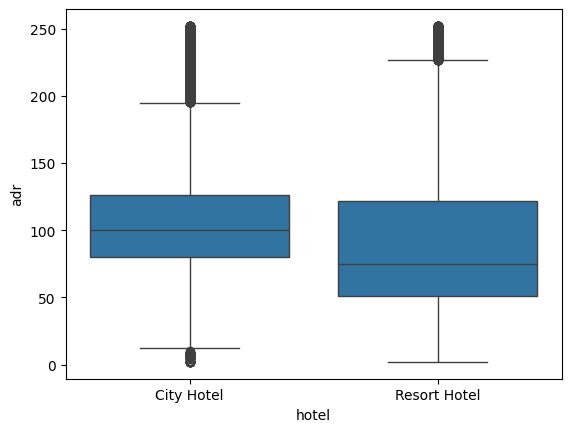

In [464]:
sns.boxplot(x='hotel', y='adr', data=df)
plt.show()

##Salud del dataset


###Valores faltantes

In [465]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

,0
hotel,0.0
is_canceled,0.0
lead_time,0.0
stays_in_weekend_nights,0.0
stays_in_week_nights,0.0
adults,0.0
children,0.0
babies,0.0
meal,0.0
market_segment,0.0


###Distribución de variables clave

In [466]:
#@title Reservas canceladas
df['is_canceled'].value_counts(normalize=True)

,proportion
is_canceled,
0,0.624989
1,0.375011


In [467]:
#@title Tarifa media diaria
df['adr'].describe()

,adr
count,116210.000000
mean,101.688476
std,43.079469
min,2.000000
25%,70.000000
50%,95.000000
75%,125.100000
max,252.000000


###Correlación final

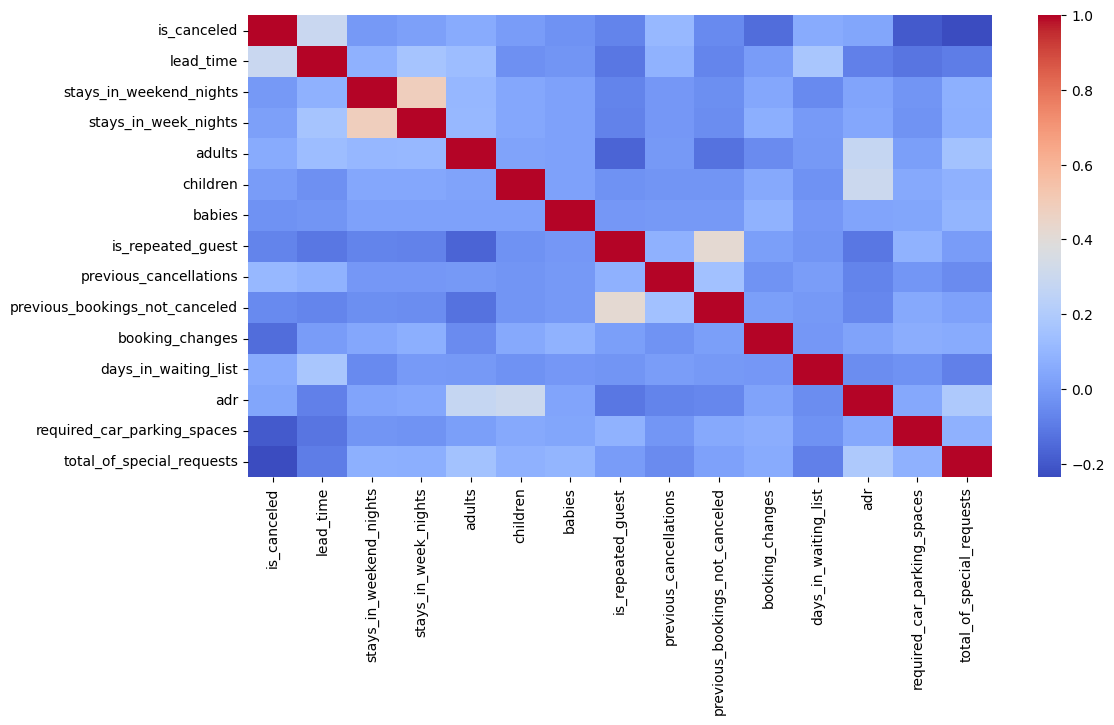

In [468]:
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

## Exportado del dataset limpio

In [469]:
df.to_csv("hotel_bookings_clean.csv", index=False)

##Conclusión

Tras la limpieza del dataset, se han eliminado duplicados, tratado valores nulos y corregido tipos de datos.
Se han detectado y gestionado outliers en variables numéricas como ADR.
El análisis de correlación no muestra redundancia crítica entre variables.
El dataset final presenta un alto nivel de calidad, siendo apto para análisis exploratorio avanzado y modelos predictivos.